In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [23]:
df = pd.read_csv("dataset.csv")

In [25]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [21]:
df = df.dropna()

In [24]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [31]:
df.shape

(114000, 22)

In [26]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [27]:
df['Popular'] = (df['popularity'] >= 60).astype(int)

In [32]:
X = df[['danceability',
        'energy',
        'loudness',
        'speechiness',
        'acousticness',
        'instrumentalness',
        'liveness',
        'valence',
        'tempo']]
print(X)

        danceability  energy  loudness  speechiness  acousticness  \
0              0.676  0.4610    -6.746       0.1430        0.0322   
1              0.420  0.1660   -17.235       0.0763        0.9240   
2              0.438  0.3590    -9.734       0.0557        0.2100   
3              0.266  0.0596   -18.515       0.0363        0.9050   
4              0.618  0.4430    -9.681       0.0526        0.4690   
...              ...     ...       ...          ...           ...   
113995         0.172  0.2350   -16.393       0.0422        0.6400   
113996         0.174  0.1170   -18.318       0.0401        0.9940   
113997         0.629  0.3290   -10.895       0.0420        0.8670   
113998         0.587  0.5060   -10.889       0.0297        0.3810   
113999         0.526  0.4870   -10.204       0.0725        0.6810   

        instrumentalness  liveness  valence    tempo  
0               0.000001    0.3580   0.7150   87.917  
1               0.000006    0.1010   0.2670   77.489  
2     

In [33]:
y = df['Popular']
y

,Popular
0,1
1,0
2,0
3,1
4,1
...,...
113995,0
113996,0
113997,0
113998,0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
model = SVC(kernel='rbf')

model.fit(X_train, y_train)

SVC()

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred)

0.8712719298245614

In [17]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      1.00      0.93     19865
           1       0.00      0.00      0.00      2935

    accuracy                           0.87     22800
   macro avg       0.44      0.50      0.47     22800
weighted avg       0.76      0.87      0.81     22800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


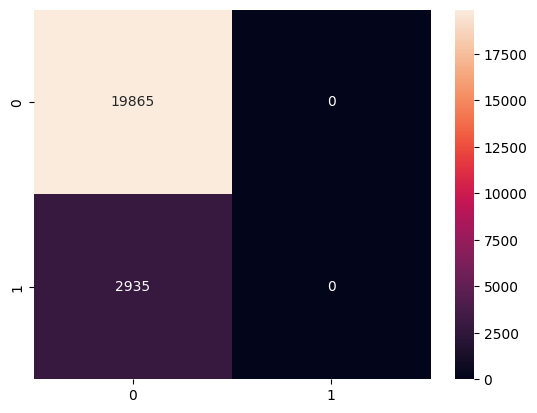

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.show()

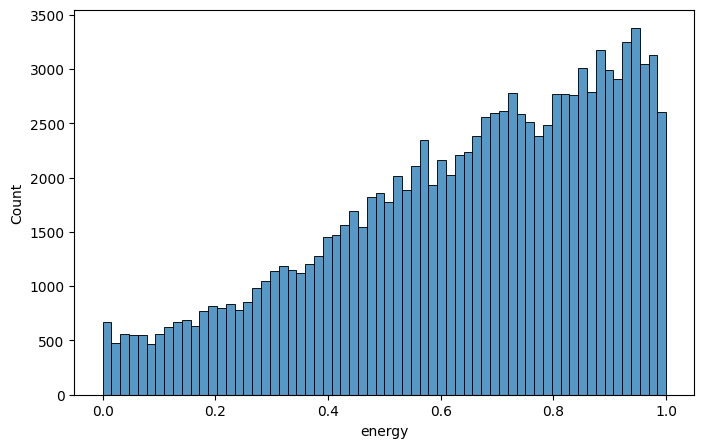

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['energy'])

plt.show()